Dataset shape: (5512903, 37)
Overall cancellation rate: 1.57 %


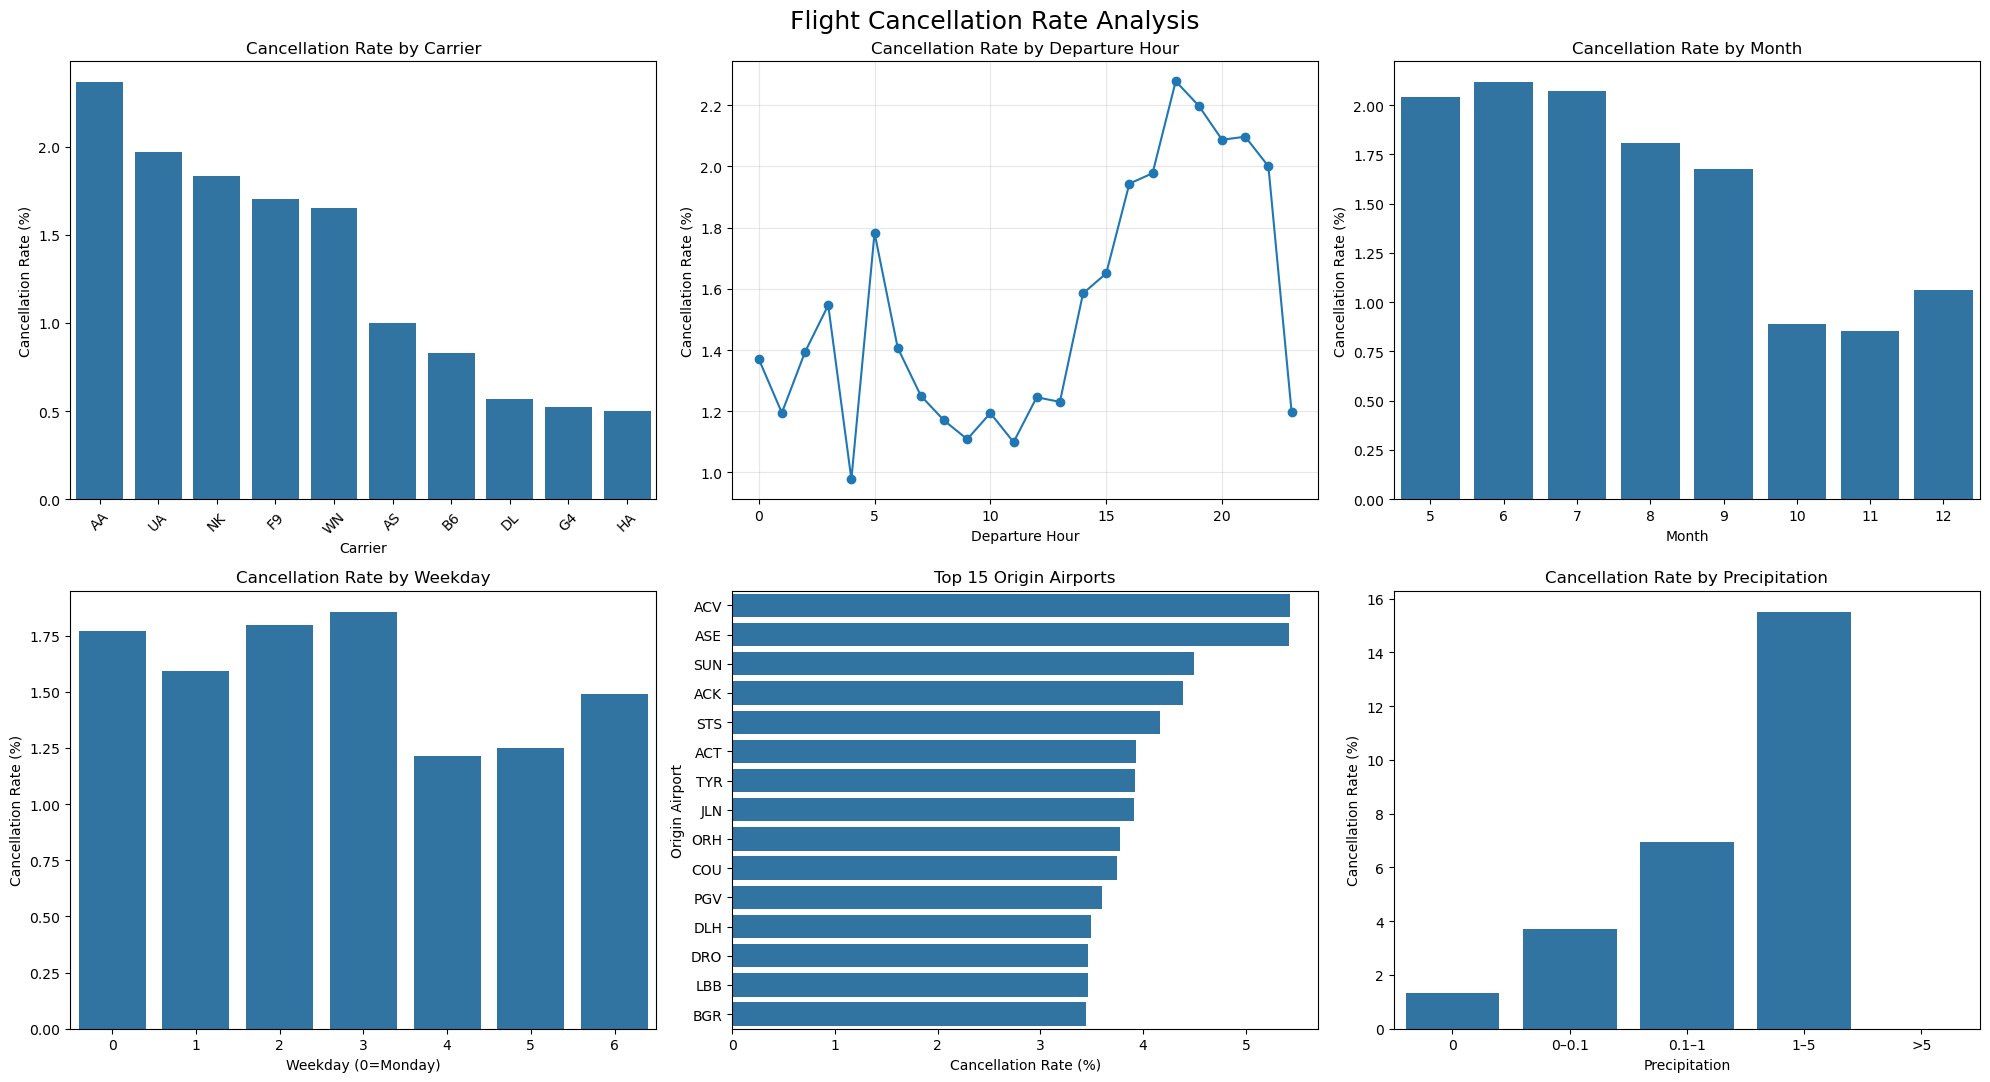

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path=r"C:\Users\S.Lefakis\Documents\Project3\Data\merged_flight_weather.csv"

df=pd.read_csv(path)

df["Cancelled"]=(df["cancelled_code"]!="N").astype(int)

df["date"]=pd.to_datetime(df["date"],errors="coerce")
df["scheduled_departure_dt"]=pd.to_datetime(df["scheduled_departure_dt"],errors="coerce")

df["departure_hour"]=df["scheduled_departure_dt"].dt.hour

print("Dataset shape:",df.shape)
print("Overall cancellation rate:",round(df["Cancelled"].mean()*100,2),"%")

fig,axes=plt.subplots(2,3,figsize=(20,11))

carrier=df.groupby("carrier_code")["Cancelled"].mean().mul(100).sort_values(ascending=False)
sns.barplot(x=carrier.index,y=carrier.values,ax=axes[0,0])
axes[0,0].set_title("Cancellation Rate by Carrier")
axes[0,0].set_xlabel("Carrier")
axes[0,0].set_ylabel("Cancellation Rate (%)")
axes[0,0].tick_params(axis="x",rotation=45)

hour=df.groupby("departure_hour")["Cancelled"].mean().mul(100)
axes[0,1].plot(hour.index,hour.values,marker="o")
axes[0,1].set_title("Cancellation Rate by Departure Hour")
axes[0,1].set_xlabel("Departure Hour")
axes[0,1].set_ylabel("Cancellation Rate (%)")
axes[0,1].grid(alpha=.3)

month=df.groupby("month")["Cancelled"].mean().mul(100)
sns.barplot(x=month.index,y=month.values,ax=axes[0,2])
axes[0,2].set_title("Cancellation Rate by Month")
axes[0,2].set_xlabel("Month")
axes[0,2].set_ylabel("Cancellation Rate (%)")

weekday=df.groupby("weekday")["Cancelled"].mean().mul(100)
sns.barplot(x=weekday.index,y=weekday.values,ax=axes[1,0])
axes[1,0].set_title("Cancellation Rate by Weekday")
axes[1,0].set_xlabel("Weekday (0=Monday)")
axes[1,0].set_ylabel("Cancellation Rate (%)")

origin=df.groupby("origin_airport")["Cancelled"].agg(["mean","count"])
origin=origin[origin["count"]>=1000]
origin=origin["mean"].mul(100).sort_values(ascending=False).head(15)

sns.barplot(x=origin.values,y=origin.index,ax=axes[1,1])
axes[1,1].set_title("Top 15 Origin Airports")
axes[1,1].set_xlabel("Cancellation Rate (%)")
axes[1,1].set_ylabel("Origin Airport")

df["precip_bin"]=pd.cut(
    df["HourlyPrecipitation_x"],
    bins=[-float("inf"),0,0.1,1,5,float("inf")],
    labels=["0","0–0.1","0.1–1","1–5",">5"]
)

precip=df.groupby("precip_bin",observed=True)["Cancelled"].mean().mul(100)

sns.barplot(x=precip.index,y=precip.values,ax=axes[1,2])
axes[1,2].set_title("Cancellation Rate by Precipitation")
axes[1,2].set_xlabel("Precipitation")
axes[1,2].set_ylabel("Cancellation Rate (%)")

plt.suptitle("Flight Cancellation Rate Analysis",fontsize=18)
plt.tight_layout()
plt.show()

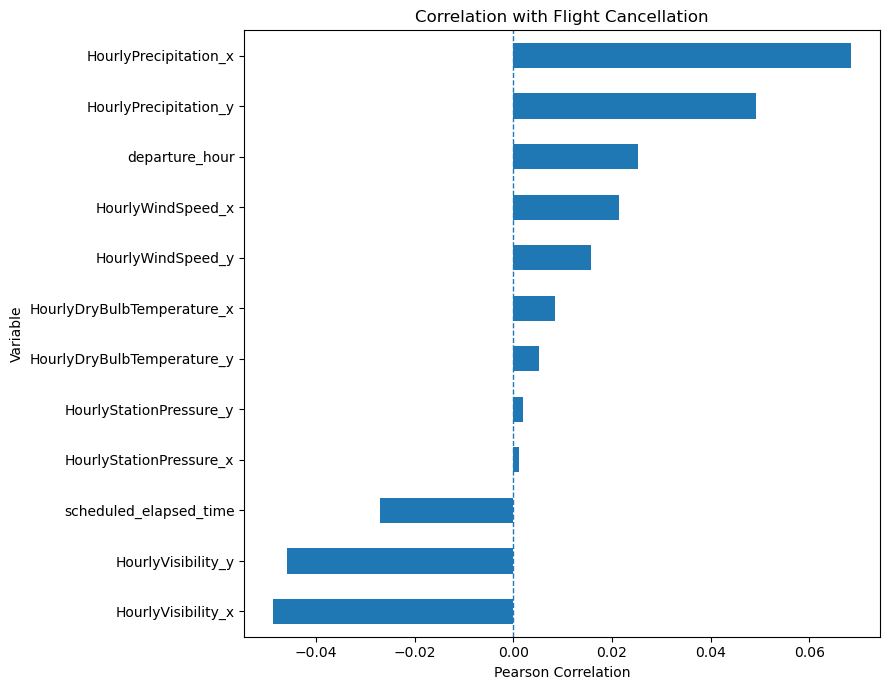


Correlation with Cancellation:
HourlyVisibility_x           -0.048766
HourlyVisibility_y           -0.045900
scheduled_elapsed_time       -0.027175
HourlyStationPressure_x       0.001077
HourlyStationPressure_y       0.001915
HourlyDryBulbTemperature_y    0.005273
HourlyDryBulbTemperature_x    0.008434
HourlyWindSpeed_y             0.015682
HourlyWindSpeed_x             0.021414
departure_hour                0.025255
HourlyPrecipitation_y         0.049144
HourlyPrecipitation_x         0.068482
Name: Cancelled, dtype: float64


In [4]:
numeric_cols=[
    "Cancelled",
    "scheduled_elapsed_time",
    "departure_hour",
    "HourlyDryBulbTemperature_x",
    "HourlyPrecipitation_x",
    "HourlyStationPressure_x",
    "HourlyVisibility_x",
    "HourlyWindSpeed_x",
    "HourlyDryBulbTemperature_y",
    "HourlyPrecipitation_y",
    "HourlyStationPressure_y",
    "HourlyVisibility_y",
    "HourlyWindSpeed_y"
]

corr=df[numeric_cols].corr()["Cancelled"].sort_values()

plt.figure(figsize=(9,7))
corr.drop("Cancelled").plot(kind="barh")
plt.title("Correlation with Flight Cancellation")
plt.xlabel("Pearson Correlation")
plt.ylabel("Variable")
plt.axvline(0,linestyle="--",linewidth=1)
plt.tight_layout()
plt.show()

print("\nCorrelation with Cancellation:")
print(corr.drop("Cancelled"))